In [17]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pprint import pprint
from util.load import DataLoader
from util.backtest import Backtest
from util.plot import (
    create_pairwise_scatter_plot,
    create_correlation_matrix,
    plot_backtest_results,
)

In [18]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 100
df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="polysignal"
)
df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-03-25: 100%|██████████| 57/57 [00:00<00:00, 82.38it/s] 


,time_to_strike,day_forecast_strike_dev,current_forecast_strike_dev,day_current_forecast_dev,day_wind_gusts_max,day_wind_speed_max,day_cloud_cover_max,day_cloud_cover_min,day_sunshine_duration,hour_wind_gusts,...,yes_price_sentiment_60,count_sentiment_60,yes_price_trend_60,count_agg_120,yes_price_vol_120,count_vol_120,taker_side_sentiment_120,yes_price_sentiment_120,count_sentiment_120,yes_price_trend_120
0,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
1,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
2,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
3,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4
4,86378.686,1.3,-12.1,13.4,51.8,27.5,99,0,41428.27,18.4,...,43.333,100.733,-4,1511,2.637,99.877,1.0,43.333,100.733,-4


In [19]:
print(df.columns)

Index(['time', 'trade_id', 'ticker', 'time_to_strike',
       'day_forecast_strike_dev', 'current_forecast_strike_dev',
       'day_current_forecast_dev', 'day_wind_gusts_max', 'day_wind_speed_max',
       'day_cloud_cover_max', 'day_cloud_cover_min', 'day_sunshine_duration',
       'hour_wind_gusts', 'hour_wind_speed', 'hour_cloud_cover',
       'hour_cloud_cover_high', 'kalshi_strike_dev', 'polymk_strike_dev',
       'kalshi_polymk_dev', 'kalshi_day_forecast_dev',
       'polymk_day_forecast_dev', 'day_forecast_percipitation',
       'day_forecast_rain', 'hour_forecast_rain', 'yes_price', 'no_price',
       'taker_side', 'count', 'shift', 'strike_m_5.0', 'strike_m_3.0',
       'strike_m_1.0', 'strike_p_1.0', 'strike_p_3.0', 'strike_p_5.0',
       'polymk_0_strike_m_5.0', 'polymk_1_strike_m_3.0',
       'polymk_2_strike_m_1.0', 'polymk_3_strike_p_1.0',
       'polymk_4_strike_p_3.0', 'polymk_5_strike_p_5.0', 'impact', 'result',
       'outcome', 'count_agg_2', 'yes_price_vol_2', 'coun

In [20]:
df.describe()

,time,time_to_strike,day_forecast_strike_dev,current_forecast_strike_dev,day_current_forecast_dev,day_wind_gusts_max,day_wind_speed_max,day_cloud_cover_max,day_cloud_cover_min,day_sunshine_duration,...,yes_price_sentiment_60,count_sentiment_60,yes_price_trend_60,count_agg_120,yes_price_vol_120,count_vol_120,taker_side_sentiment_120,yes_price_sentiment_120,count_sentiment_120,yes_price_trend_120
count,70995,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,...,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000,70995.000000
mean,2025-04-25 17:26:16.885629952,46963.342557,0.050235,-7.022159,7.072394,41.489704,22.278484,93.271188,18.436411,27330.025333,...,35.405927,31.171504,-2.183731,7267.687654,6.937485,51.377053,0.570072,34.886134,30.122946,-3.456384
min,2025-03-24 23:59:21.313972,7.319000,-13.100000,-34.400000,-0.900000,18.400000,14.100000,0.000000,0.000000,0.000000,...,3.000000,1.000000,-93.000000,1.000000,0.000000,0.000000,0.000000,3.000000,1.000000,-90.000000
25%,2025-04-11 15:21:23.592326912,36076.183000,-1.400000,-10.900000,1.900000,35.300000,18.400000,100.000000,0.000000,9149.330000,...,17.951000,15.280000,-8.000000,3454.500000,2.567000,24.592000,0.451000,18.884000,16.459000,-10.000000
50%,2025-04-27 16:09:59.938629888,44588.567000,0.100000,-5.200000,4.500000,41.000000,20.700000,100.000000,0.000000,33584.730000,...,33.500000,24.469000,-1.000000,6115.000000,5.153000,39.850000,0.580000,34.011000,24.721000,-1.000000
75%,2025-05-12 10:54:32.082612992,53732.225500,1.700000,-2.000000,11.200000,47.500000,25.600000,100.000000,16.000000,43388.540000,...,48.808500,38.737000,4.000000,9621.000000,9.607000,63.269000,0.706000,47.455000,36.790000,5.000000
max,2025-05-23 17:12:07.087360,86399.922000,11.100000,6.400000,32.200000,62.600000,36.000000,100.000000,100.000000,49087.670000,...,97.000000,900.000000,85.000000,37019.000000,34.136000,716.283000,1.000000,97.000000,900.000000,78.000000
std,NaN,16595.456954,2.543424,6.696652,6.799154,10.377267,5.078786,21.968571,33.597440,17557.172893,...,21.176942,27.914419,16.639763,5563.178125,5.803894,44.871908,0.206095,19.732350,23.791958,19.213754


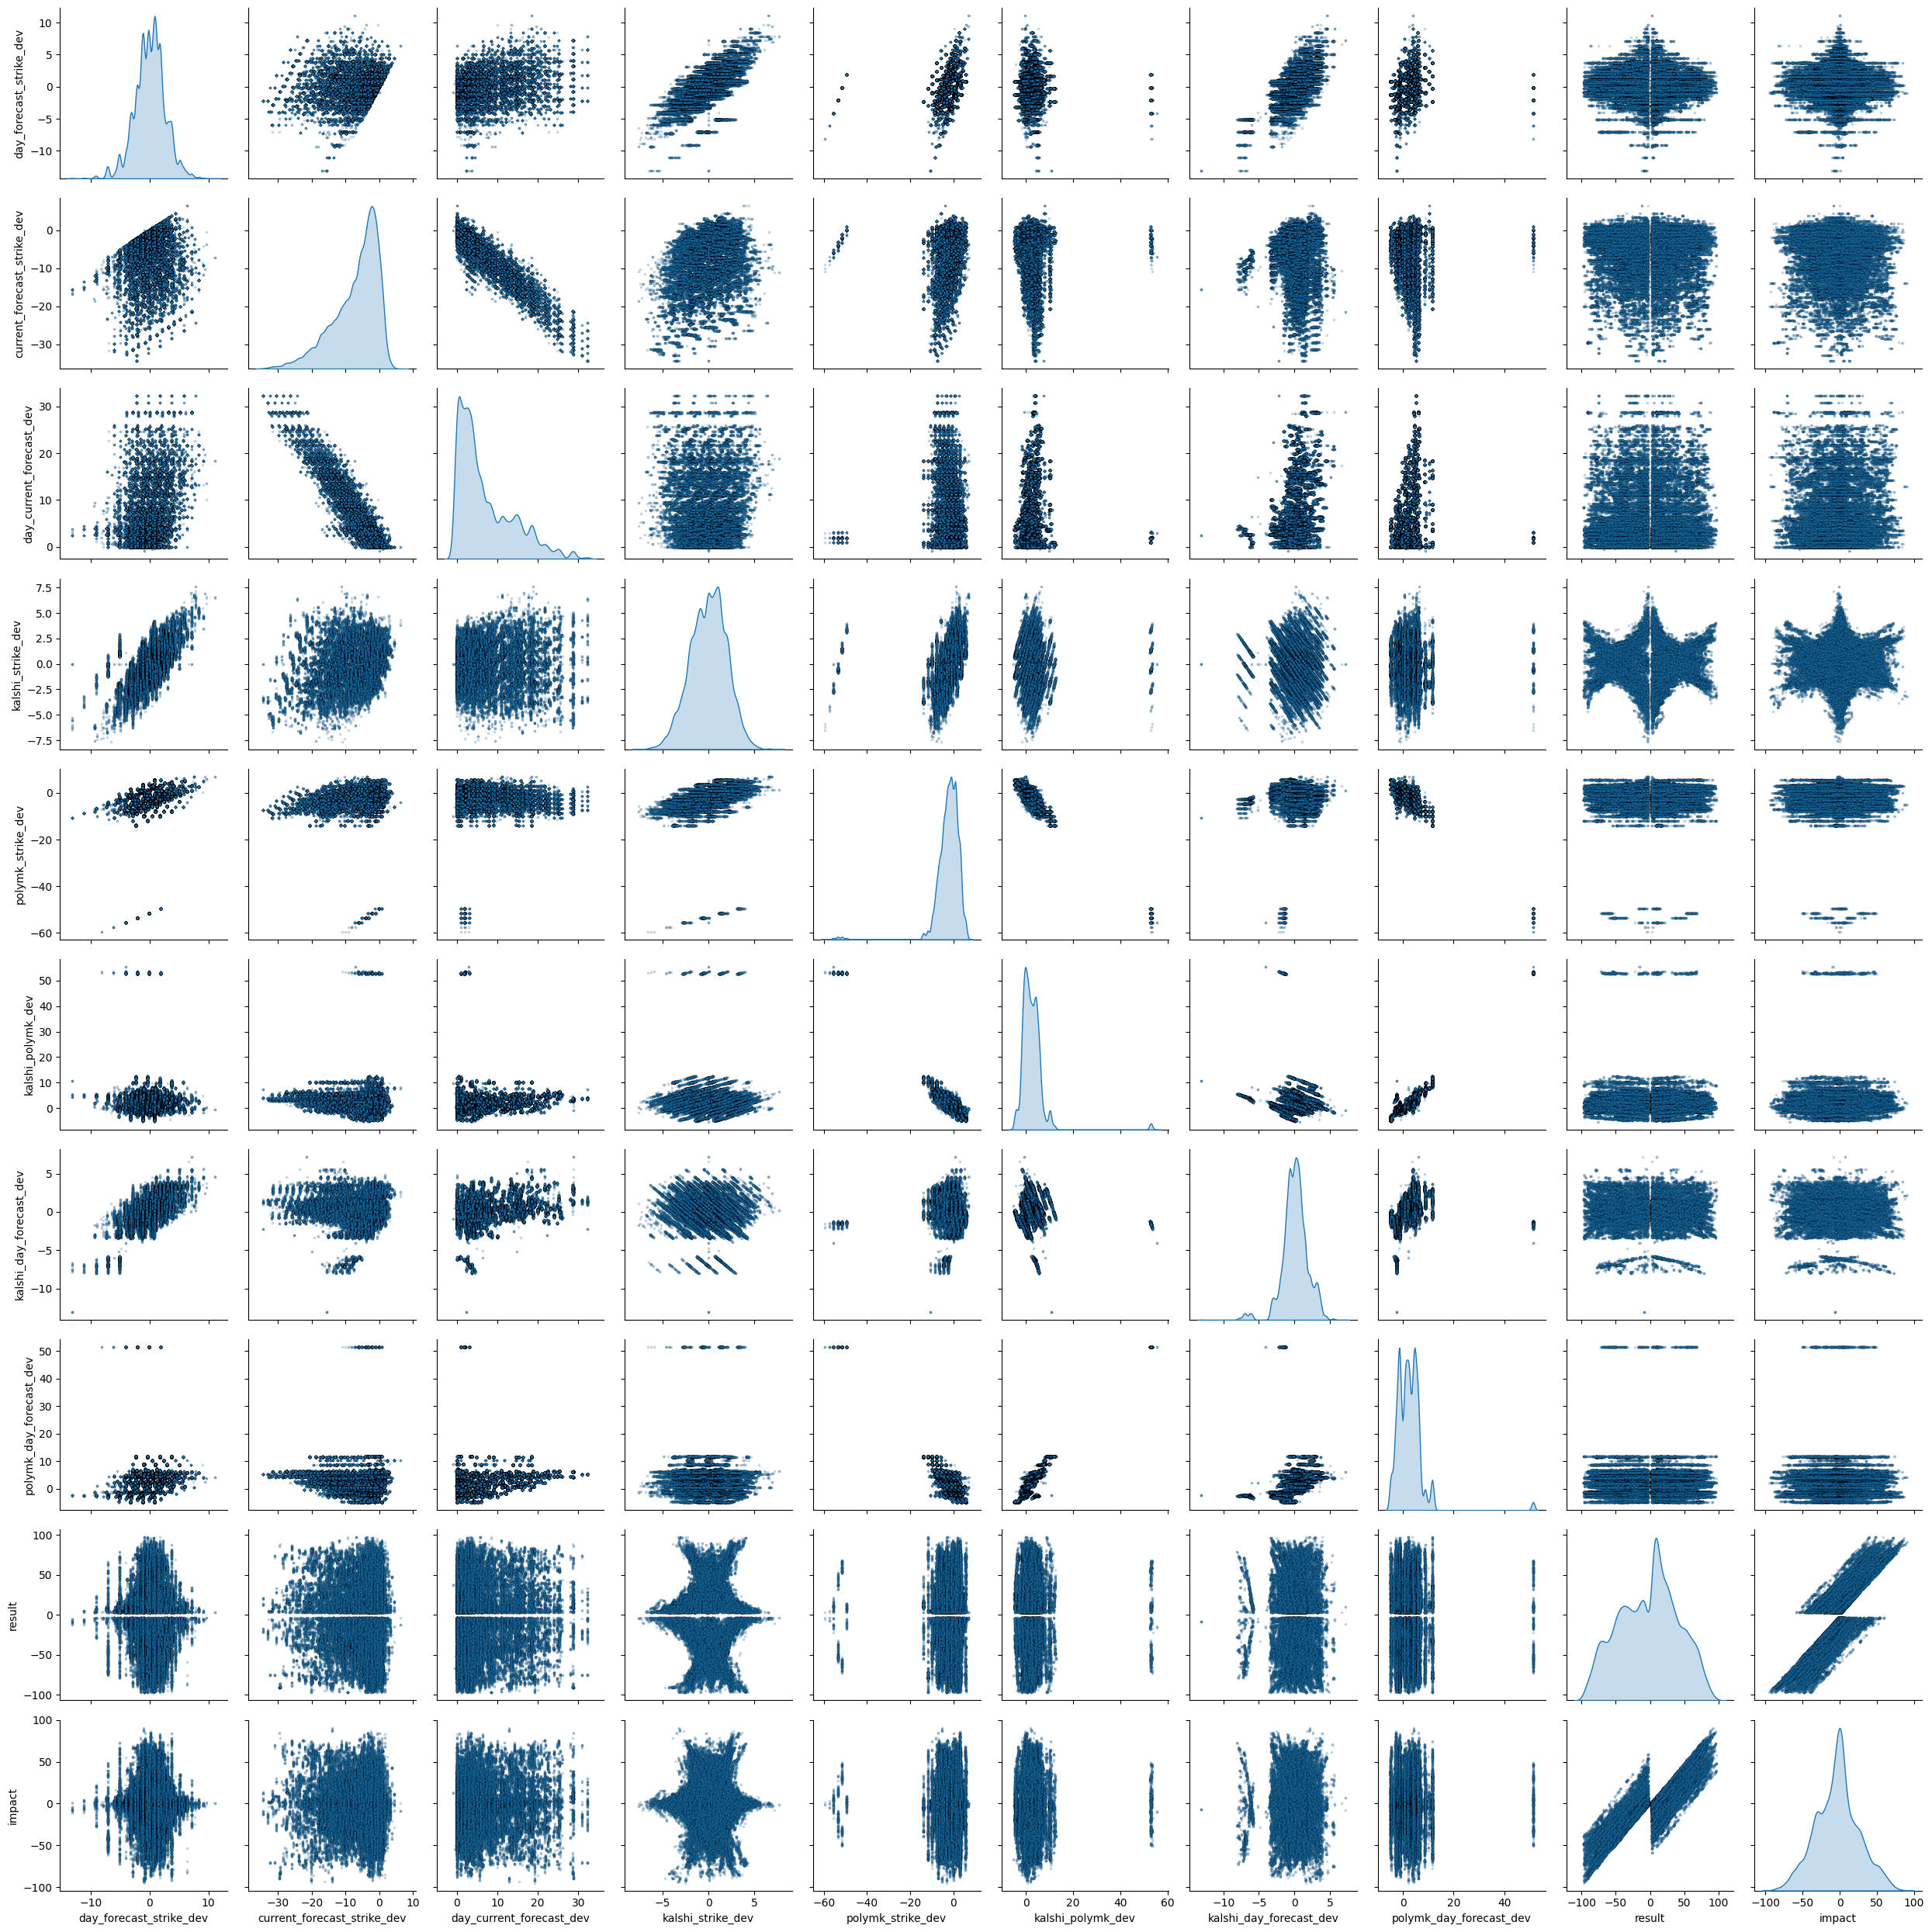

In [4]:
dev_features = [f for f in df.columns if f.endswith("dev")]
create_pairwise_scatter_plot(df, dev_features + ["result", "impact"])

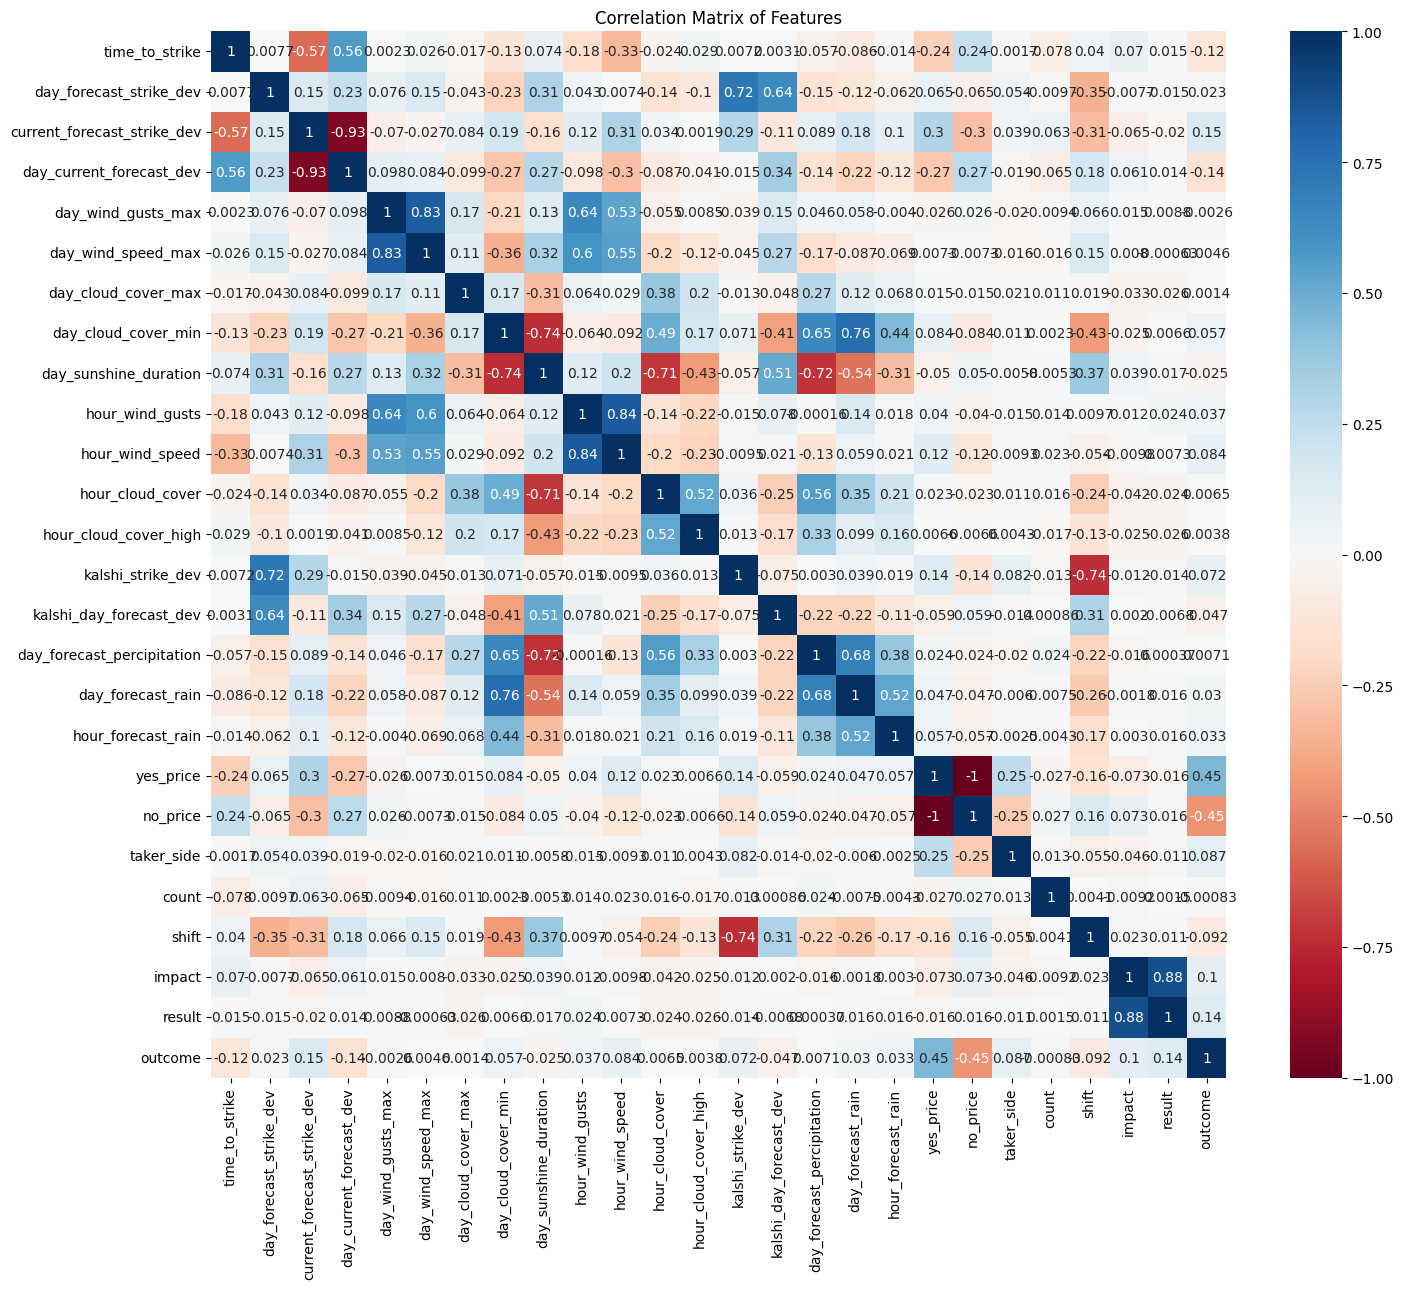

In [21]:
market_features = [
    f
    for f in df.columns.tolist()
    if not f.split("_")[-1].isdigit() and f not in ["time", "ticker", "trade_id"] and not f[-1].isdigit() and 'polymk' not in f
]
create_correlation_matrix(df, market_features)

2025-05-14 | R2 train: 0.017693425999631973, R2 test: -0.04557521823857158 | Corr train: 0.13301663819800538, Corr test: -0.006510871794597272
2025-05-15 | R2 train: 0.016522465852735313, R2 test: -0.06372399216951741 | Corr train: 0.1285397443998601, Corr test: -0.23632869252444416
2025-05-16 | R2 train: 0.014683872649592478, R2 test: -0.028022693508245267 | Corr train: 0.12117703024791093, Corr test: -0.0008408492745327116
2025-05-17 | R2 train: 0.01403013196290459, R2 test: 0.01628858532095767 | Corr train: 0.11844885804372429, Corr test: 0.1783419743621478
2025-05-18 | R2 train: 0.014548308611408323, R2 test: -0.069942881853166 | Corr train: 0.1206163696134391, Corr test: -0.1294606746450326
2025-05-19 | R2 train: 0.013339984183442732, R2 test: -0.008485857995700341 | Corr train: 0.1154988492911198, Corr test: 0.028096036377946634
2025-05-20 | R2 train: 0.013083382695409096, R2 test: -0.006479175727897912 | Corr train: 0.1143826153803203, Corr test: 0.023631143243905254
2025-05-21 

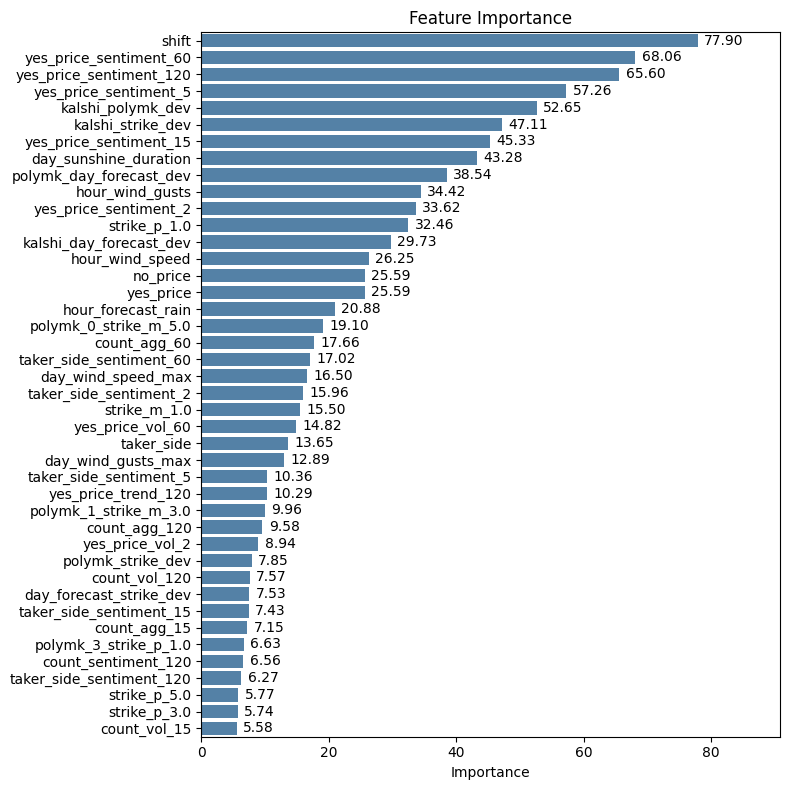

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    QuantileRegressor,
    BayesianRidge,
    Ridge,
)
from sklearn.model_selection import TimeSeriesSplit

# turn time into datetime object


def plot_feature_importances(df, threshold=1):
    df["time"] = pd.to_datetime(df["time"])
    df["date"] = df["time"].dt.date
    exclude = np.array(
        ["time", "result", "impact", "ticker", "trade_id", "outcome", "date"]
    )
    features = np.array([f for f in df.columns.tolist() if f not in exclude])
    tscv = TimeSeriesSplit(n_splits=10, test_size=1)
    feature_importances = np.zeros(len(features))

    for train_index, test_index in tscv.split(df["date"].unique()):
        train_dates, test_dates = (
            df["date"].unique()[train_index],
            df["date"].unique()[test_index],
        )
        train_data, test_data = (
            df[df["date"].isin(train_dates)],
            df[df["date"].isin(test_dates)],
        )

        # scaler = RobustScaler(unit_variance=True)
        scaler = RobustScaler(unit_variance=True)
        train_data[features] = scaler.fit_transform(train_data[features])
        test_data[features] = scaler.transform(test_data[features])
        lasso = Ridge(alpha=0.1)
        lasso.fit(train_data[features], train_data["result"])
        # rf = RandomForestRegressor(n_estimators=100, random_state=42)
        # rf.fit(train_data[features], train_data["result"])
        r2_train = lasso.score(train_data[features], train_data["result"])
        r2_test = lasso.score(test_data[features], test_data["result"])
        corr_train = np.corrcoef(
            lasso.predict(train_data[features]), train_data["result"]
        )[0, 1]
        corr_test = np.corrcoef(
            lasso.predict(test_data[features]), test_data["result"]
        )[0, 1]
        print(
            f"{test_dates[0]} | R2 train: {r2_train}, R2 test: {r2_test} | Corr train: {corr_train}, Corr test: {corr_test}"
        )
        feature_importances += lasso.coef_

    feature_importances = abs(feature_importances)
    sorted_idx = np.argsort(feature_importances)[::-1]
    features, feature_importances = (
        features[sorted_idx],
        feature_importances[sorted_idx],
    )
    features = features[feature_importances > threshold]
    feature_importances_df = pd.DataFrame(
        {
            "Feature": features,
            "Importance": feature_importances[feature_importances > threshold],
        }
    )

    plt.figure(figsize=(8, 8))
    ax = sns.barplot(
        y="Feature", x="Importance", data=feature_importances_df, color="steelblue"
    )
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("")
    for i, bar in enumerate(ax.patches):
        width = bar.get_width()
        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            ha="left",
            va="center",
        )
    current_xlim = plt.xlim()
    plt.xlim(current_xlim[0], current_xlim[1] + 9)
    plt.tight_layout()
    plt.show()


plot_feature_importances(df, threshold=5)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    QuantileRegressor,
    BayesianRidge,
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF


class Model(object):

    def __init__(
        self,
        output_metric: str = "result",
        features: list[str] = None,
        outlier_threshold: float = 0.00,
    ):
        self.output_metric = output_metric
        self.features = features
        self.outlier_threshold = outlier_threshold
        self.pipeline = Pipeline(
            [
                ("robust_scaler", RobustScaler(unit_variance=True)),
                (
                    "quantile_transformer",
                    QuantileTransformer(n_quantiles=100, output_distribution="normal"),
                ),
                (
                    "voting",
                    VotingRegressor(
                        estimators=[
                            (
                                "gb",
                                GradientBoostingRegressor(
                                    n_estimators=50,
                                    learning_rate=0.01,
                                    max_depth=4,
                                    subsample=0.5,
                                    min_samples_split=50,
                                    random_state=42,
                                ),
                            ),
                            (
                                "rf",
                                RandomForestRegressor(
                                    n_estimators=50, max_depth=3, random_state=42
                                ),
                            ),
                            ("lasso", Lasso(alpha=0.1)),
                            ("knn", KNeighborsRegressor(n_neighbors=25)),
                        ],
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    def __call__(
        self, train_data: pd.DataFrame, input_data: pd.DataFrame
    ) -> pd.DataFrame:
        if self.features is None:
            self.features = [
                f
                for f in train_data.columns.tolist()
                if (
                    f
                    not in ["time", "result", "impact", "ticker", "trade_id", "outcome"]
                )
                and 'polymk' not in f
            ]
            # print(self.features)
        self.pipeline.fit(train_data[self.features], train_data[self.output_metric])
        input_predictions = self.pipeline.predict(input_data[self.features])
        train_predictions = self.pipeline.predict(train_data[self.features])
        return train_predictions, input_predictions

100%|██████████| 57/57 [05:55<00:00,  6.24s/it]


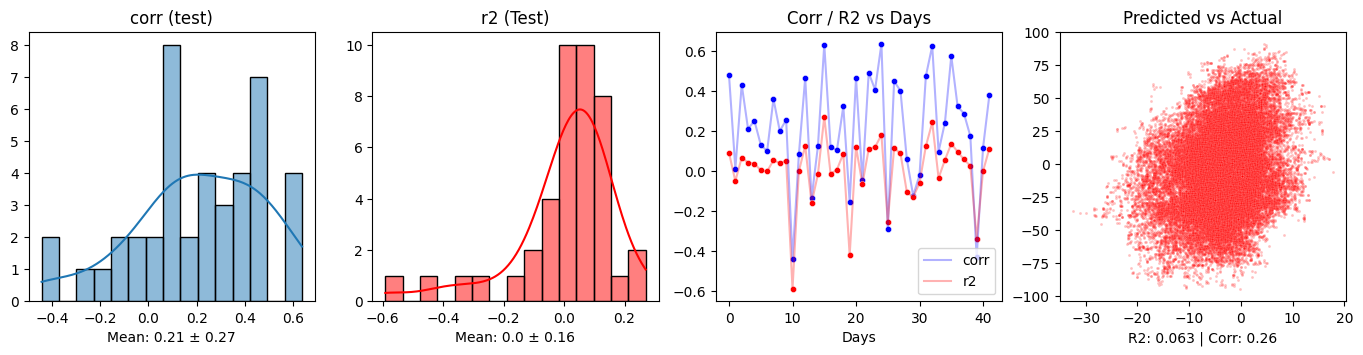

In [23]:
min_window_size, max_window_size, backtest_window = 15, 30, 50

output_metric = "impact"
backtest = Backtest("kxhighny", data_dir="../data", backtest_window=backtest_window)
model = Model(features=None, output_metric=output_metric)

results, predictions, day_predictions = backtest.get_backtest_stats(
    model,
    min_window_size,
    max_window_size,
    output_metric=output_metric,
    # scaler=QuantileTransformer(n_quantiles=100, output_distribution="uniform")
    # scaler=QuantileTransformer(n_quantiles=100, output_distribution="normal")
)
plot_backtest_results(results, predictions)

In [9]:
results[results["r2_test"] > -0.1].mean()

r2_train      0.319033
r2_test       0.060219
corr_train    0.753227
corr_test     0.295196
dtype: float64

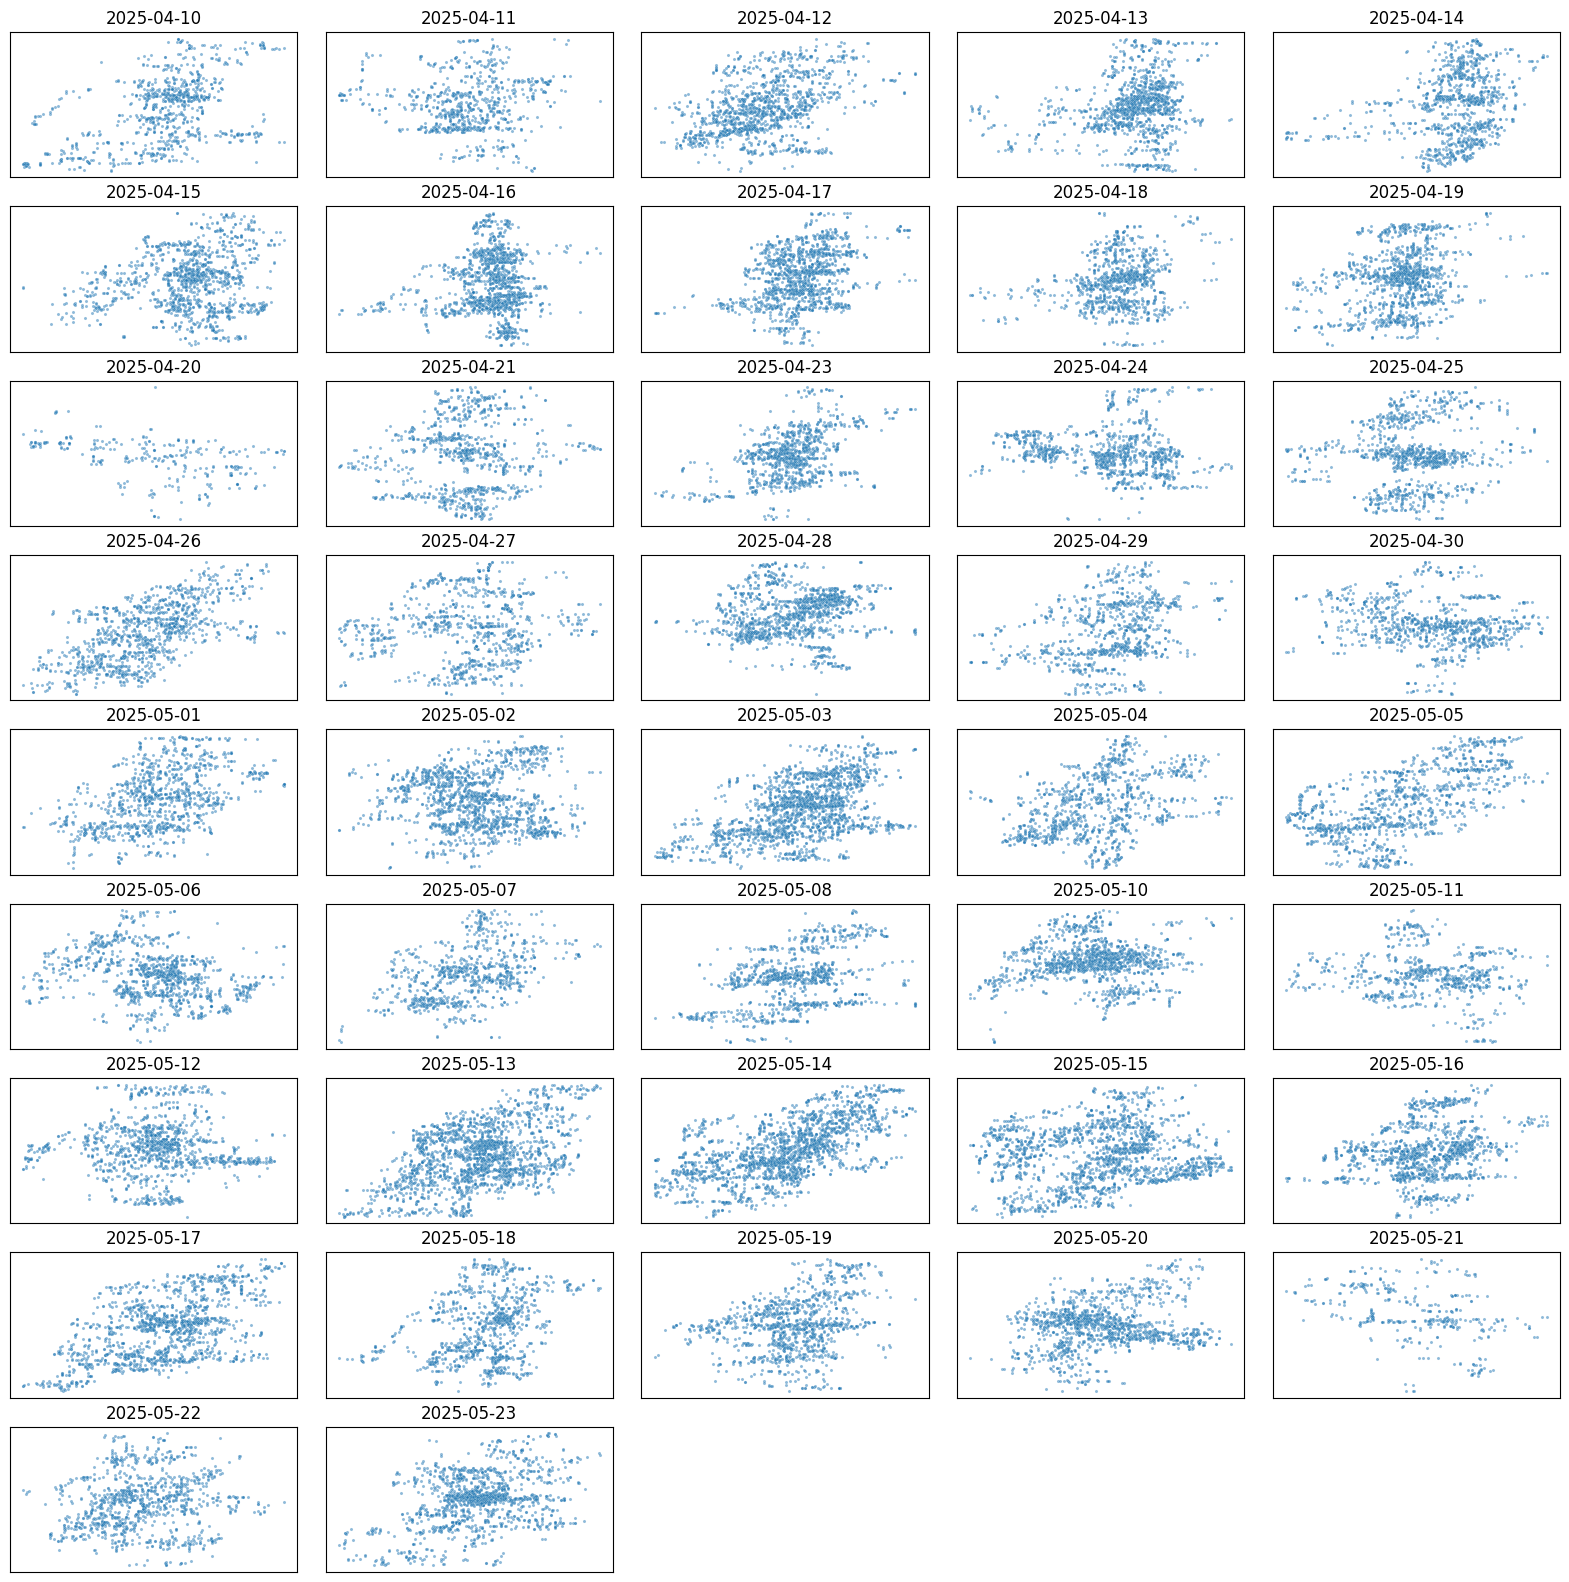

In [24]:
dates = sorted(list(day_predictions.keys()))
fig, axs = plt.subplots(len(dates) // 5 + 1, 5, figsize=(20, 20))

# Add padding between subplots
plt.subplots_adjust(hspace=0.2, wspace=0.1)

for i in range(0, len(dates), 5):
    for idx, date in enumerate(dates[i : i + 5]):
        if i // 5 < axs.shape[0] and idx < axs.shape[1]:  # Check if the subplot exists
            sns.scatterplot(
                x="impact_pred",
                y="impact",
                data=day_predictions[date],
                ax=axs[i // 5, idx],
                alpha=0.5,
                s=5,
            )
            axs[i // 5, idx].set_title(date)
            axs[i // 5, idx].xaxis.set_visible(False)
            axs[i // 5, idx].yaxis.set_visible(False)

# Hide empty subplots in the last row
for i in range(len(dates), (len(dates) // 5 + 1) * 5):
    row = i // 5
    col = i % 5
    if row < axs.shape[0] and col < axs.shape[1]:
        axs[row, col].set_visible(False)
plt.show()

In [13]:
for date, df in day_predictions.items():
    strike_cols = [c for c in df.columns if c.startswith("strike_")]
    polymk_cols = [c for c in df.columns if c.startswith("polymk_")]
    df = df[df['time_to_strike'] < 60000]
    print(df.iloc[0][strike_cols])
    print(df.iloc[0][polymk_cols])
    break

strike_m_5.0     6
strike_m_3.0    31
strike_m_1.0    49
strike_p_1.0    14
strike_p_3.0     3
strike_p_5.0     0
Name: 121, dtype: object
polymk_strike_dev         -2.045
polymk_day_forecast_dev    1.045
polymk_0_strike_m_5.0       50.5
polymk_1_strike_m_3.0       63.0
polymk_2_strike_m_1.0       80.0
polymk_3_strike_p_1.0       87.5
polymk_4_strike_p_3.0       91.0
polymk_5_strike_p_5.0      98.55
Name: 121, dtype: object
